## Lab 5 — Exploratory Data Analysis (EDA)
**Dataset: Titanic Passenger Data**


#### Objectives

1. Understand the structure and contents of the Titanic dataset

2. Identify missing values and understand data quality

3. Analyze survival patterns based on passenger features like gender, class, age, and fare

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (891, 12)


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

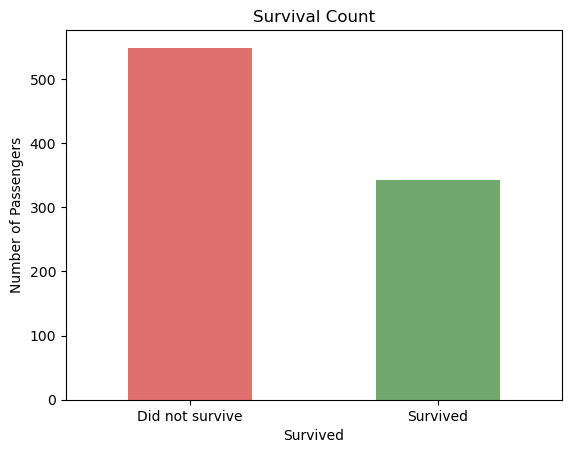

In [9]:
# Figure 1
df['Survived'].value_counts().plot(kind='bar', color=['#e07070','#70a870'])
plt.title('Survival Count')
plt.xticks([0,1], ['Did not survive','Survived'], rotation=0)
plt.ylabel('Number of Passengers')
plt.show()

**Analysis**

Only **38.4%** of passengers survived. The majority — 549 out of 891 — did not make it.

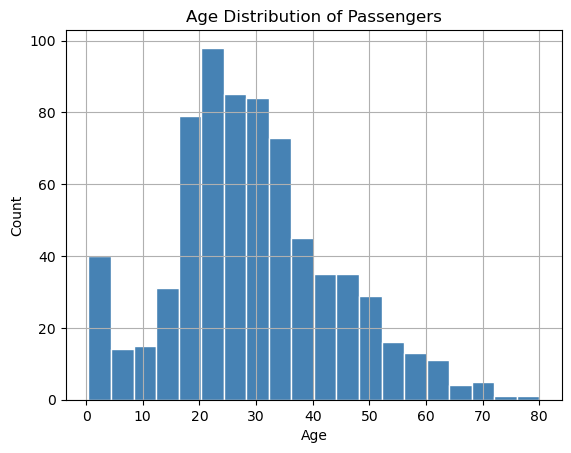

In [11]:
# Figure 2
df['Age'].dropna().hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Analysis**

The age distribution is roughly bell-shaped, with most passengers between **20–40 years.** 
There are also a small number of very young children (infants included).

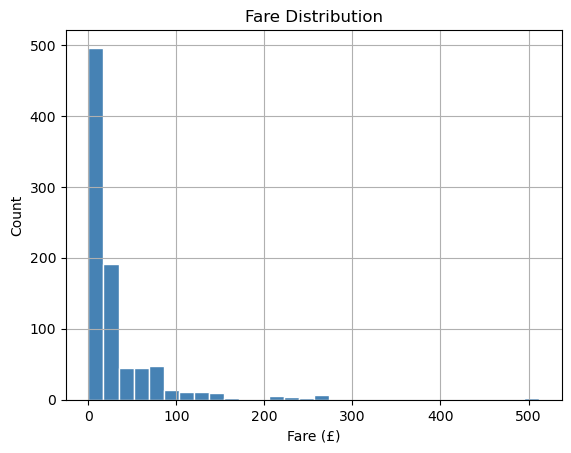

In [12]:
# Figure 3
df['Fare'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Fare Distribution')
plt.xlabel('Fare (£)')
plt.ylabel('Count')
plt.show()

Fare is **heavily right-skewed** — most people paid low fares (under £30), but a small number paid extremely high fares (up to £512). This matches the class imbalance we saw — most passengers were in 3rd class.

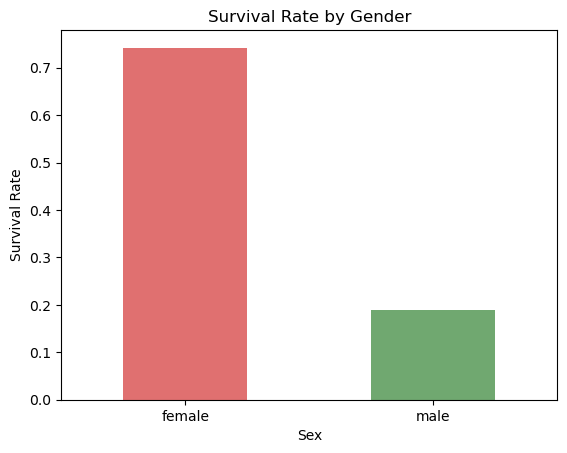

In [13]:
# Figure 4
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['#e07070','#70a870'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

This is one of the most striking findings. **Women had a 74% survival rate while men had only 19%**. The "women and children first" evacuation policy is clearly reflected here.

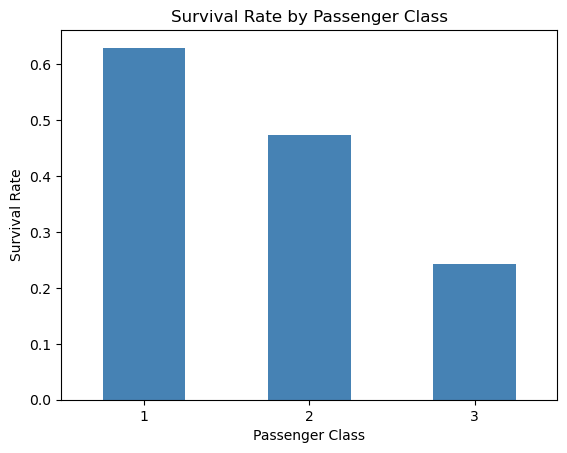

In [14]:
# Figure 5
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

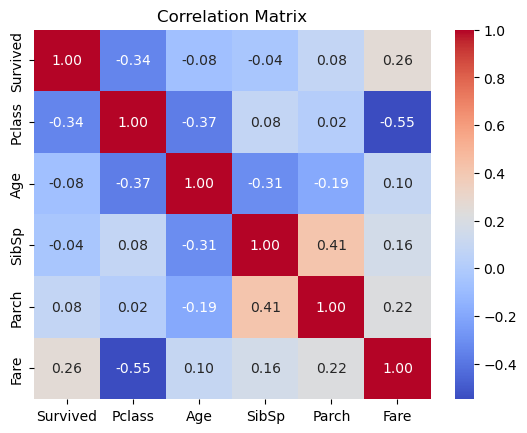

In [15]:
# Figure 6
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Pclass** has the strongest negative correlation with survival (higher class number = worse survival). **Fare** has a positive correlation — passengers who paid more tended to survive more, which ties back to class.
